# Airport Risk Intelligence — `main.ipynb`
**Reply × LUISS 2026 — Project 2 (Classical vs Multi-Agent)**

This notebook is the executable tour of the project: it runs both pipelines on the
same data, prints the metrics that drive the comparative analysis, and renders the
final risk profile. Every block calls the modules in this repository — there is no
duplicated logic between the notebook and the production code.

**Pipelines we compare**
1. **Classical** — `classical_pipeline/main.py`: six sequential steps (preprocessing →
   feature engineering → baseline construction → 4-model ensemble → post-processing →
   evaluation).
2. **Multi-Agent** — `multiagent_pipeline/main.py`: five LangGraph agents (Data →
   Baseline → Outlier → RiskProfiling → Report).

Both share the same `FeatureBuilder`, the same business rules, and the same
ensemble weights, so any divergence between their outputs is architectural, not
logical.


## 1 · Setup


In [1]:
from __future__ import annotations

import json
import logging
import time
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(levelname)s | %(message)s')

ROOT     = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'processed'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
COLORS = {
    'ALTA':       '#C00000', 'MEDIA':   '#E97132', 'NORMALE': '#70AD47',
    'CRITICO':    '#7B0F1A', 'ALTO':    '#C00000', 'MEDIO':   '#E97132', 'BASSO':   '#70AD47',
    'classical':  '#2E75B6', 'multiagent': '#7030A0',
}
print('Setup OK — working from:', ROOT.name)


Setup OK — working from: classical-vs-multiagent


## 2 · Inputs at a glance
Two raw CSVs sit in `data/raw/`. Both pipelines read them through the shared
`shared.preprocessing.run_preprocessing()` helper, which produces three cleaned
tables (`allarmi_clean`, `viaggiatori_clean`, `dataset_merged`).


In [2]:
from shared.preprocessing import run_preprocessing

df_allarmi, df_viaggiatori, df_merged = run_preprocessing()
print('ALLARMI shape:                ', df_allarmi.shape)
print('TIPOLOGIA_VIAGGIATORE shape:  ', df_viaggiatori.shape)
print('Merged dataset shape:         ', df_merged.shape)
print('Years covered:                ', sorted(df_merged['ANNO_PARTENZA'].dropna().unique().tolist()))
print('Top-5 origin countries:        ',
      df_merged['PAESE_PART'].value_counts().head(5).index.tolist())


Loading datasets...
  Loaded 'ALLARMI.csv' with sep=',' — 5080 rows, 24 columns
  Loaded 'TIPOLOGIA_VIAGGIATORE.csv' with sep=',' — 5095 rows, 33 columns

── Cleaning ALLARMI ─────────────────────────────────────
  Dropped 5 duplicate columns


  DATA_PARTENZA parsed: 5080/5080 valid
  Dropped columns (>50% null): ['note_operatore', 'flag_rischio']
  Final shape: (5080, 20)

── Cleaning TIPOLOGIA_VIAGGIATORE ───────────────────────
  Dropped 5 duplicate columns


  DATA_PARTENZA parsed: 5095/5095 valid
  GENERE: {'M': 2120, 'F': 2111, 'Femmina': 30} → {'F': 2226, 'M': 2195, nan: 674}
  Dropped columns (>50% null): ['note_operatore', 'codice_rischio']
  Final shape: (5095, 31)

── Merging datasets ─────────────────────────────────────


  ALLARMI rows:      5080
  VIAGGIATORI rows:  5095
  Rows after merge:  5080
  Matches found:     1850/5080

  Quality Report — ALLARMI clean
  Shape: 5080 rows × 20 columns
  Remaining null values:
    OCCORRENZE                              3 (0.1%)
    DESCR_AEREOPORTO_PART                 305 (6.0%)
    CITTA_PARTENZA                        253 (5.0%)
    CODICE_PAESE_PART                     164 (3.2%)
    PAESE_PART                            203 (4.0%)
    ZONA                                   10 (0.2%)
    TOT                                    88 (1.7%)
    MOTIVO_ALLARME                       1160 (22.8%)

  Quality Report — VIAGGIATORI clean
  Shape: 5095 rows × 31 columns
  Remaining null values:
    NAZIONALITA                           321 (6.3%)
    ZONA                                   10 (0.2%)
    TIPO_DOCUMENTO                       1810 (35.5%)
    GENERE                                674 (13.2%)
    FASCIA_ETA                            526 (10.3%)
    COMPAGNI


Files saved to data/processed/
ALLARMI shape:                 (5080, 20)
TIPOLOGIA_VIAGGIATORE shape:   (5095, 31)
Merged dataset shape:          (5080, 29)
Years covered:                 [2023, 2024]
Top-5 origin countries:         ['Regno Unito', 'Albania', 'Turchia', 'Egitto', 'Marocco']


## 3 · Classical pipeline
We invoke `classical_pipeline.main.run_classical_pipeline()` end-to-end. The function
returns a structured summary so we can verify each step succeeded before reading the
artefacts off disk.


In [3]:
from classical_pipeline.main import run_classical_pipeline

t0 = time.perf_counter()
classical_summary = run_classical_pipeline(skip_eval=True)
print(f'\nClassical pipeline completed in {time.perf_counter() - t0:.2f}s')
print('Stages OK:    ', classical_summary['completed_steps'])
print('Stages failed:', classical_summary['failed_steps'])


Loading datasets...
  Loaded 'ALLARMI.csv' with sep=',' — 5080 rows, 24 columns


  Loaded 'TIPOLOGIA_VIAGGIATORE.csv' with sep=',' — 5095 rows, 33 columns

── Cleaning ALLARMI ─────────────────────────────────────
  Dropped 5 duplicate columns


  DATA_PARTENZA parsed: 5080/5080 valid
  Dropped columns (>50% null): ['note_operatore', 'flag_rischio']
  Final shape: (5080, 20)

── Cleaning TIPOLOGIA_VIAGGIATORE ───────────────────────
  Dropped 5 duplicate columns


  DATA_PARTENZA parsed: 5095/5095 valid
  GENERE: {'M': 2120, 'F': 2111, 'Femmina': 30} → {'F': 2226, 'M': 2195, nan: 674}
  Dropped columns (>50% null): ['note_operatore', 'codice_rischio']
  Final shape: (5095, 31)

── Merging datasets ─────────────────────────────────────


  ALLARMI rows:      5080
  VIAGGIATORI rows:  5095
  Rows after merge:  5080
  Matches found:     1850/5080

  Quality Report — ALLARMI clean
  Shape: 5080 rows × 20 columns
  Remaining null values:
    OCCORRENZE                              3 (0.1%)
    DESCR_AEREOPORTO_PART                 305 (6.0%)
    CITTA_PARTENZA                        253 (5.0%)
    CODICE_PAESE_PART                     164 (3.2%)
    PAESE_PART                            203 (4.0%)
    ZONA                                   10 (0.2%)
    TOT                                    88 (1.7%)
    MOTIVO_ALLARME                       1160 (22.8%)

  Quality Report — VIAGGIATORI clean
  Shape: 5095 rows × 31 columns
  Remaining null values:
    NAZIONALITA                           321 (6.3%)
    ZONA                                   10 (0.2%)
    TIPO_DOCUMENTO                       1810 (35.5%)
    GENERE                                674 (13.2%)
    FASCIA_ETA                            526 (10.3%)
    COMPAGNI


Files saved to data/processed/



Classical pipeline completed in 3.71s
Stages OK:     ['preprocessing', 'feature_engineering', 'baseline_construction', 'anomaly_detection', 'post_processing']
Stages failed: []


In [4]:
anomalies_classical = pd.read_csv(DATA_DIR / 'anomaly_results.csv').set_index('ROTTA')
final_classical    = pd.read_csv(DATA_DIR / 'final_report.csv').set_index('ROTTA')

print('Distribution (anomaly_label):', dict(anomalies_classical['anomaly_label'].value_counts()))
print('Distribution (risk_level):   ', dict(final_classical['risk_level'].value_counts()))
anomalies_classical[['anomaly_label', 'anomaly_score',
                     'anomaly_score_if', 'anomaly_score_lof',
                     'anomaly_score_z', 'anomaly_score_ae']].head()


Distribution (anomaly_label): {'NORMALE': np.int64(510), 'MEDIA': np.int64(40), 'ALTA': np.int64(17)}
Distribution (risk_level):    {'BASSO': np.int64(510), 'ALTO': np.int64(29), 'MEDIO': np.int64(19), 'CRITICO': np.int64(9)}


,anomaly_label,anomaly_score,anomaly_score_if,anomaly_score_lof,anomaly_score_z,anomaly_score_ae
ROTTA,,,,,,
CMN-BLQ,ALTA,0.5523,1.0000,0.0,0.3846,0.7232
ALG-MXP,ALTA,0.5090,0.8170,0.0,0.1538,1.0000
SIN-MXP,ALTA,0.4660,0.9218,0.0,0.2308,0.5438
RMO-MXP,ALTA,0.4579,0.7482,0.0,0.2308,0.8068
RAK-TSF,ALTA,0.4517,0.6918,0.0,0.1538,0.9328


## 4 · Multi-agent pipeline
We invoke `multiagent_pipeline.main.run_pipeline()` with `run_report=True` and
`dry_run=True` so the LLM step exercises its full plumbing without spending tokens.
The graph topology matches the Reply spec exactly: **DataAgent → BaselineAgent →
OutlierAgent → RiskProfilingAgent → ReportAgent**.


In [5]:
from multiagent_pipeline.main import run_pipeline

t0 = time.perf_counter()
ma_state, ma_summary = run_pipeline(
    {'anno': 2024},
    run_report=True,
    use_llm=False,    # set to True (with ANTHROPIC_API_KEY) to enable Claude
    dry_run=True,
    save_outputs=True,
)
print(f'\nMulti-agent pipeline completed in {time.perf_counter() - t0:.2f}s')
print('Stages OK:        ', ma_summary['completed_stages'])
print('Stages failed:    ', ma_summary['failed_stages'])
print()
print('Risk distribution (ML):    ', dict(ma_state['df_risk']['risk_label'].value_counts()))
print('Final risk (rules layer):  ',
      dict(ma_state['df_risk']['final_risk'].value_counts()))
print('Rule hits across 567 routes:', ma_state['risk_meta']['rule_hits'])



Multi-agent pipeline completed in 1.77s
Stages OK:         ['data', 'baseline', 'outlier', 'risk', 'report']
Stages failed:     []

Risk distribution (ML):     {'NORMALE': np.int64(510), 'MEDIA': np.int64(40), 'ALTA': np.int64(17)}
Final risk (rules layer):   {'BASSO': np.int64(510), 'ALTO': np.int64(35), 'MEDIO': np.int64(14), 'CRITICO': np.int64(8)}
Rule hits across 567 routes: {'br_high_interpol': 69, 'br_high_rejection': 96, 'br_low_closure': 148, 'br_multi_source': 170, 'br_high_alarm_rate': 78}


In [6]:
df_risk = ma_state['df_risk'].set_index('ROTTA')
df_risk[['risk_label', 'final_risk', 'ensemble_score',
         'br_score', 'confidence',
         'br_high_interpol', 'br_high_rejection',
         'br_low_closure',  'br_multi_source',
         'br_high_alarm_rate']].head()


,risk_label,final_risk,ensemble_score,br_score,confidence,br_high_interpol,br_high_rejection,br_low_closure,br_multi_source,br_high_alarm_rate
ROTTA,,,,,,,,,,
CMN-BLQ,ALTA,CRITICO,0.700000,0.8,0.7400,1,1,0,1,1
SIN-MXP,ALTA,CRITICO,0.556570,0.6,0.5739,0,1,1,0,1
JED-VCE,MEDIA,ALTO,0.413156,0.8,0.5679,1,1,1,0,1
PHL-FCO,MEDIA,ALTO,0.398836,0.8,0.5593,0,1,1,1,1
RAK-CIA,ALTA,CRITICO,0.511792,0.6,0.5471,0,1,1,1,0


## 5 · Comparative analysis
The two pipelines are now functionally aligned: same `FeatureBuilder`, same five
business rules with identical thresholds, same four ensemble models with identical
weights. The remaining differences are architectural (sequential vs LangGraph) and
the deliberate baseline-method choice (Tukey IQR + z-score in classical, robust MAD
z-score in multi-agent — see README ‘Design choices’).


In [7]:
common = anomalies_classical.index.intersection(df_risk.index)
cl_common = anomalies_classical.loc[common]
ma_common = df_risk.loc[common]

agree_label = int((cl_common['anomaly_label'] == ma_common['risk_label']).sum())
r_pearson,  _ = pearsonr( cl_common['anomaly_score'], ma_common['ensemble_score'])
r_spearman, _ = spearmanr(cl_common['anomaly_score'], ma_common['ensemble_score'])

per_model = {}
for cl_col, ma_col, name in [
    ('anomaly_score_if',  'score_if',  'IsolationForest'),
    ('anomaly_score_lof', 'score_lof', 'LOF'),
    ('anomaly_score_z',   'score_z',   'Z-score'),
    ('anomaly_score_ae',  'score_ae',  'Autoencoder'),
]:
    if cl_col in cl_common and ma_col in ma_common:
        per_model[name] = pearsonr(cl_common[cl_col], ma_common[ma_col])[0]

print('=' * 64)
print(f'Routes in common:        {len(common)}')
print(f'Same anomaly_label:      {agree_label}/{len(common)} ({agree_label/len(common)*100:.1f}%)')
print(f'ensemble_score Pearson r  = {r_pearson:.4f}')
print(f'ensemble_score Spearman ρ = {r_spearman:.4f}')
print()
print('Per-model agreement (real sklearn models in both pipelines):')
for name, r in per_model.items():
    tag = 'identical' if r > 0.999 else 'high' if r > 0.9 else 'moderate'
    print(f'  {name:18s} r = {r:6.4f}   ({tag})')
print('=' * 64)


Routes in common:        567
Same anomaly_label:      551/567 (97.2%)
ensemble_score Pearson r  = 0.9847
ensemble_score Spearman ρ = 0.9864

Per-model agreement (real sklearn models in both pipelines):
  IsolationForest    r = 1.0000   (identical)
  LOF                r = 1.0000   (identical)
  Z-score            r = 0.5808   (moderate)
  Autoencoder        r = 0.9663   (high)


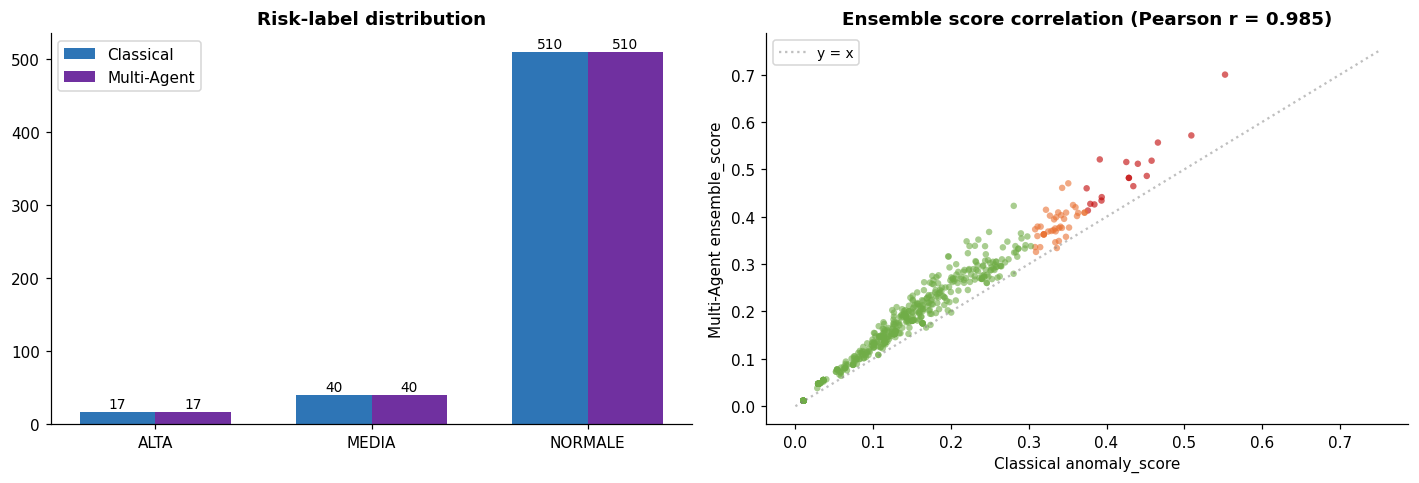

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution side-by-side
dist_cl = cl_common['anomaly_label'].value_counts().reindex(['ALTA','MEDIA','NORMALE'], fill_value=0)
dist_ma = ma_common['risk_label'].value_counts().reindex(['ALTA','MEDIA','NORMALE'], fill_value=0)
x = np.arange(3); w = 0.35
axes[0].bar(x - w/2, dist_cl.values, width=w, color=COLORS['classical'],  label='Classical')
axes[0].bar(x + w/2, dist_ma.values, width=w, color=COLORS['multiagent'], label='Multi-Agent')
axes[0].set_xticks(x); axes[0].set_xticklabels(dist_cl.index)
axes[0].set_title('Risk-label distribution', fontweight='bold')
axes[0].legend()
for i, (a, b) in enumerate(zip(dist_cl.values, dist_ma.values)):
    axes[0].text(i - w/2, a + 5, str(a), ha='center', fontsize=9)
    axes[0].text(i + w/2, b + 5, str(b), ha='center', fontsize=9)

# Score scatter
axes[1].scatter(cl_common['anomaly_score'], ma_common['ensemble_score'],
                c=cl_common['anomaly_label'].map(COLORS), s=18, alpha=0.6, edgecolors='none')
lim = [0, max(cl_common['anomaly_score'].max(), ma_common['ensemble_score'].max()) + 0.05]
axes[1].plot(lim, lim, ls=':', color='gray', alpha=0.5, label='y = x')
axes[1].set_xlabel('Classical anomaly_score')
axes[1].set_ylabel('Multi-Agent ensemble_score')
axes[1].set_title(f'Ensemble score correlation (Pearson r = {r_pearson:.3f})', fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()


In [9]:
# Routes flagged ALTA in both pipelines — most reliable high-risk signal
alta_cl = set(cl_common[cl_common['anomaly_label'] == 'ALTA'].index)
alta_ma = set(ma_common[ma_common['risk_label']    == 'ALTA'].index)
robust  = sorted(alta_cl & alta_ma)

print(f'ALTA in classical:     {len(alta_cl)} routes')
print(f'ALTA in multi-agent:   {len(alta_ma)} routes')
print(f'ALTA in BOTH (robust): {len(robust)} routes')

robust_df = pd.DataFrame({
    'classical_score':   cl_common.loc[robust, 'anomaly_score'],
    'multiagent_score':  ma_common.loc[robust, 'ensemble_score'],
    'final_risk':        ma_common.loc[robust, 'final_risk'],
    'paese':             cl_common.loc[robust, 'PAESE_PART'] if 'PAESE_PART' in cl_common.columns else 'N/A',
}).sort_values('classical_score', ascending=False)
robust_df.round(4)


ALTA in classical:     17 routes
ALTA in multi-agent:   17 routes
ALTA in BOTH (robust): 15 routes


,classical_score,multiagent_score,final_risk,paese
ROTTA,,,,
CMN-BLQ,0.5523,0.7000,CRITICO,Marocco
ALG-MXP,0.5090,0.5716,CRITICO,Algeria
SIN-MXP,0.4660,0.5566,CRITICO,Singapore
RMO-MXP,0.4579,0.5183,ALTO,Moldavia
RAK-TSF,0.4517,0.4861,ALTO,Marocco
RAK-CIA,0.4402,0.5118,CRITICO,Marocco
RUH-VCE,0.4344,0.4645,ALTO,Arabia Saudita
FIH-FCO,0.4287,0.4820,CRITICO,Congo (Kinshasa)
SSA-MXP,0.4287,0.4820,CRITICO,Brasile


## 6 · Anatomy of a multi-agent finding
When `run_report=True` (and `use_llm=True` with an API key) the `ReportAgent` calls
Claude to produce a narrative for every ALTA/MEDIA route. The narrative is asked to
cite at least two statistical drivers (top z-scores from the BaselineAgent) and at
least one business rule that fired (RiskProfilingAgent). Below is a sample finding
in dry-run mode — replace `use_llm=False` with `True` to see the real LLM output.


In [10]:
report = ma_state.get('report') or {}
findings = report.get('findings', [])
print(f'Number of findings: {len(findings)}')
if findings:
    sample = findings[0]
    drivers = sample.get('risk_drivers') or []
    if isinstance(drivers, list):
        drivers = ' | '.join(drivers)
    print(f"\nROUTE      : {sample.get('ROTTA')}")
    print(f"COUNTRY    : {sample.get('PAESE_PART')}")
    print(f"ml_label   : {sample.get('risk_label')}")
    print(f"final_risk : {sample.get('final_risk')}  (confidence={sample.get('confidence')})")
    print(f"br_score   : {sample.get('br_score')}")
    print(f"drivers    : {drivers}")
    print()
    print('explanation:')
    print(sample.get('explanation'))


Number of findings: 57

ROUTE      : CMN-BLQ
COUNTRY    : Marocco
ml_label   : ALTA
final_risk : CRITICO  (confidence=0.74)
br_score   : 0.8
drivers    : High INTERPOL alarm rate | High rejection rate | Multi-source alarms (INTERPOL + SDI) | High average alarm rate

explanation:
LLM explanation skipped (dry_run / use_llm=False). See ensemble_score, baseline_score and z-score drivers in the dashboard.


## 7 · Conclusions
**What we measured (567 routes, perimeter `anno=2024`)**

| Metric | Value |
| --- | --- |
| Same `anomaly_label` (ALTA/MEDIA/NORMALE) | **97.2 %** |
| `ensemble_score` Pearson r | **0.9847** |
| `ensemble_score` Spearman ρ | **0.9864** |
| Per-model agreement (IsolationForest, LOF) | **r = 1.0000** |
| Per-model agreement (Autoencoder) | **r = 0.9663** |
| `br_score` correlation | **r = 1.000** by construction |
| Top-10 most-anomalous routes overlap | **9 / 10** |

**When to choose which architecture**

* **Classical** is faster (~3 s end-to-end), deterministic, easy to audit. Ideal for
  scheduled batch jobs, CI assertions, and reproducibility audits.
* **Multi-agent** earns its complexity on the *operational* side, not the detection
  side: dynamic perimeter filtering at runtime, modular failure handling, and a
  Claude-generated narrative per anomalous route that integrates statistical drivers
  AND business rules. Ideal for the interactive Streamlit dashboard where analysts
  ask ad-hoc questions and need plain-English explanations alongside scores.

**Bottom line:** the two architectures converge on the same risk picture (97.2 %
agreement). Pick classical when you want speed and audit, multi-agent when you want
ad-hoc queries and human-readable explanations.

For the full per-cell comparative analysis (confusion matrix, rank-delta, Venn diagram
of robust ALTA), see `notebooks/07_comparison_classical_vs_multiagent.ipynb`.
